<a href="https://colab.research.google.com/github/sergekamanzi/Fraudent-Docs/blob/main/transaction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [81]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

In [100]:
data = pd.read_csv('/content/fraud detection.csv')
data.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,380.0,CASH_OUT,92888.94,C2054348498,27657.00,0.00,C1853199806,5838781.76,5931670.70,0.0,0.0
1,646.0,TRANSFER,399045.08,C724693370,10399045.08,10399045.08,C1909486199,0.00,0.00,1.0,1.0
2,384.0,CASH_IN,35416.73,C1095508813,1154711.52,1190128.25,C961243143,927932.70,892515.97,0.0,0.0
3,518.0,CASH_IN,52211.31,C1867780533,2985.00,55196.31,C1425168473,433652.93,381441.62,0.0,0.0
4,450.0,CASH_OUT,1463764.35,C2142422300,1463764.35,0.00,C1173885211,385211.95,1848976.30,1.0,0.0


In [101]:
# Assuming your data is in a pandas DataFrame called 'df'
unique_values = data['type'].unique()
print(unique_values)

['CASH_OUT' 'TRANSFER' 'CASH_IN' 'PAYMENT' 'DEBIT']


In [83]:
%%capture
data.describe()

In [84]:
%%capture
data.isnull().sum()

In [85]:
%%capture
data = data.drop(columns=["nameOrig", "nameDest", "isFlaggedFraud"])
data.head()

In [103]:
#%%capture
# Initialize LabelEncoder
le = LabelEncoder()

# Apply LabelEncoder to the 'type' column
data['type'] = le.fit_transform(data['type'])
data.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,380.0,1,92888.94,C2054348498,27657.00,0.00,C1853199806,5838781.76,5931670.70,0.0,0.0
1,646.0,4,399045.08,C724693370,10399045.08,10399045.08,C1909486199,0.00,0.00,1.0,1.0
2,384.0,0,35416.73,C1095508813,1154711.52,1190128.25,C961243143,927932.70,892515.97,0.0,0.0
3,518.0,0,52211.31,C1867780533,2985.00,55196.31,C1425168473,433652.93,381441.62,0.0,0.0
4,450.0,1,1463764.35,C2142422300,1463764.35,0.00,C1173885211,385211.95,1848976.30,1.0,0.0


In [104]:
# Assuming your data is in a pandas DataFrame called 'df'
unique_values = data['type'].unique()
print(unique_values)

[1 4 0 3 2]


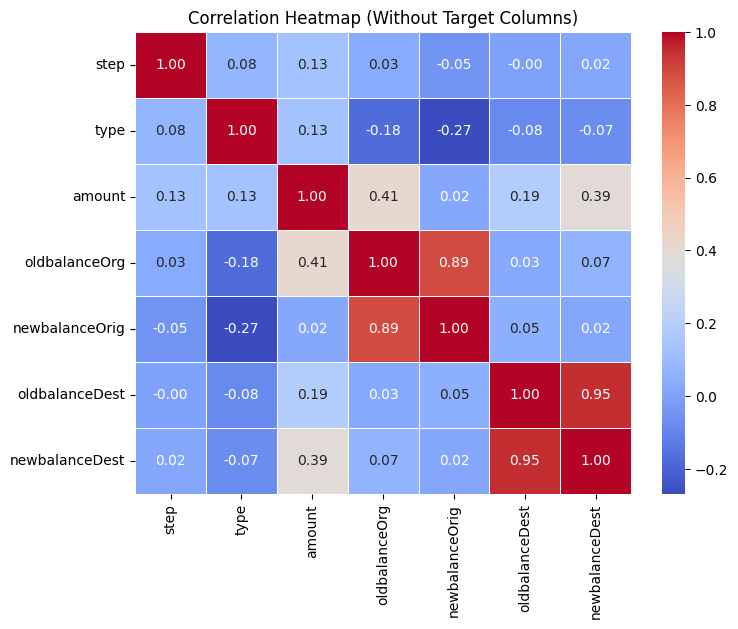

In [87]:
# Compute the correlation matrix
corr_matrix = data.drop(columns=['isFraud']).corr()

# Create the heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap (Without Target Columns)')
plt.show()


In [88]:
data.shape

(7050, 8)

In [89]:
# Initialize the StandardScaler
scaler = StandardScaler()

# List of numeric columns to scale (excluding target variables like isFraud)
numeric_cols = ['step', 'amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest']

# Apply the scaler to the numeric columns
data[numeric_cols] = scaler.fit_transform(data[numeric_cols])

In [90]:
# Define features and target labels
X = data.drop(columns=['isFraud'])
Y = data['isFraud']

In [91]:
# Split data into train, validation, and test sets
X_train, X_temp, Y_train, Y_temp = train_test_split(X, Y, test_size=0.3, random_state=42)
X_val, X_test, Y_val, Y_test = train_test_split(X_temp, Y_temp, test_size=0.5, random_state=42)

# Compute class weights
class_weights = compute_class_weight(class_weight="balanced", classes=np.unique(Y_train), y=Y_train)
class_weight_dict = {0: class_weights[0], 1: class_weights[1]}

In [92]:
# Build Neural Network model
model = Sequential([
    Dense(64, activation='relu', kernel_regularizer=l2(0.01), input_shape=(X_train.shape[1],)),
    Dense(32, activation='relu', kernel_regularizer=l2(0.01)),
    Dense(1, activation='sigmoid')
])


In [93]:
# Compile model
model.compile(optimizer=Adam(learning_rate=0.001), loss='binary_crossentropy', metrics=['accuracy'])

# Define Early Stopping
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

In [94]:
%%capture
# Train model
history = model.fit(X_train, Y_train, validation_data=(X_val, Y_val), epochs=50, batch_size=32,
                    class_weight=class_weight_dict, callbacks=[early_stopping], verbose=1)

# Evaluate model
Y_pred = (model.predict(X_test) > 0.5).astype("int32")

In [95]:
# Compute metrics
accuracy = accuracy_score(Y_test, Y_pred)
precision = precision_score(Y_test, Y_pred)
recall = recall_score(Y_test, Y_pred)
f1 = f1_score(Y_test, Y_pred)
conf_matrix = confusion_matrix(Y_test, Y_pred)

# Print metrics
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)
print("Confusion Matrix:\n", conf_matrix)


Accuracy: 0.9385633270321361
Precision: 0.9140893470790378
Recall: 0.869281045751634
F1 Score: 0.8911222780569514
Confusion Matrix:
 [[727  25]
 [ 40 266]]


In [96]:
# Function to predict fraud based on user input
def predict_fraud():
    print("Enter transaction details below:")
    step = float(input("Step: "))
    type_ = int(input("Type (Enter 0 for CASH_IN, 1 for CASH_OUT, etc.): "))
    amount = float(input("Amount: "))
    oldbalanceOrg = float(input("Old Balance Origin: "))
    newbalanceOrig = float(input("New Balance Origin: "))
    oldbalanceDest = float(input("Old Balance Destination: "))
    newbalanceDest = float(input("New Balance Destination: "))

    user_input = pd.DataFrame([[step, type_, amount, oldbalanceOrg, newbalanceOrig, oldbalanceDest, newbalanceDest]],
                              columns=X.columns)
    user_input[numeric_cols] = scaler.transform(user_input[numeric_cols])
    prediction = (model.predict(user_input) > 0.5).astype("int32")[0, 0]

    print("Prediction:", "Fraud" if prediction == 1 else "No Fraud")

# Run prediction function
predict_fraud()


Enter transaction details below:
Step: 646.0	
Type (Enter 0 for CASH_IN, 1 for CASH_OUT, etc.): 4
Amount: 399045.08	
Old Balance Origin: 10399045.08
New Balance Origin: 10399045.08
Old Balance Destination: 0.00	
New Balance Destination: 0.00	
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
Prediction: Fraud
